# NeuroGolf Debug Notebook
Visual debugging for the D4 Permutation Architecture pipeline.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

sys.path.insert(0, os.path.abspath('.'))
from main import (
    load_task, find_rule, TRANSFORMS, build_perm_indices,
    build_onnx_model, grid_to_onehot, verify_model, STRIDE
)

TASKS_DIR = os.path.join('..', 'neurogolf-2026')

# ARC color palette
COLORS = [
    '#000000', '#1E93FF', '#F2314E', '#4ECC30', '#FFDD00',
    '#999999', '#E53BA3', '#FF851C', '#88D8F1', '#931131',
    '#F0F0F0', '#927556'
]
CMAP = ListedColormap(COLORS)

def plot_grid(ax, grid, title='', fontsize=14):
    """Render a 2D grid as a colored image."""
    H = len(grid)
    W = len(grid[0])
    arr = np.array(grid)
    ax.imshow(arr, cmap=CMAP, vmin=0, vmax=11, interpolation='nearest')
    ax.set_title(title, fontsize=fontsize, fontweight='bold')
    ax.set_xticks(range(W))
    ax.set_yticks(range(H))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    for r in range(H):
        for c in range(W):
            val = grid[r][c]
            color = 'white' if val in [0, 9] else 'black'
            ax.text(c, r, str(val), ha='center', va='center',
                    fontsize=10, color=color, fontweight='bold')

def plot_diff(ax, expected, actual, title=''):
    """Show a diff grid: green=same, red=different."""
    H = len(expected)
    W = len(expected[0])
    diff = np.zeros((H, W, 3))
    for r in range(H):
        for c in range(W):
            if expected[r][c] == actual[r][c]:
                diff[r][c] = [0.85, 1.0, 0.85]  # light green
            else:
                diff[r][c] = [1.0, 0.75, 0.75]  # light red
    ax.imshow(diff, interpolation='nearest')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(range(W))
    ax.set_yticks(range(H))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    for r in range(H):
        for c in range(W):
            e, a = expected[r][c], actual[r][c]
            marker = '' if e == a else f'{e}→{a}'
            color = 'green' if e == a else 'red'
            if marker:
                ax.text(c, r, marker, ha='center', va='center',
                        fontsize=7, color=color, fontweight='bold')

print('Ready.')

Ready.


## 1. Pick a task to inspect
Change `TASK_NUM` to explore any task.

In [7]:
TASK_NUM = 7  # <-- change this

task = load_task(TASK_NUM)
print(f'Task {TASK_NUM:03d} | train: {len(task["train"])} demos | test: {len(task["test"])} | arc-gen: {len(task["arc-gen"])}')
for i, ex in enumerate(task['train']):
    print(f'  demo {i}: input {len(ex["input"])}x{len(ex["input"][0])} -> output {len(ex["output"])}x{len(ex["output"][0])}')

Task 007 | train: 3 demos | test: 1 | arc-gen: 262
  demo 0: input 7x7 -> output 7x7
  demo 1: input 7x7 -> output 7x7
  demo 2: input 7x7 -> output 7x7


## 2. Rule Detection
Which D4 symmetry was found (if any)?

In [8]:
all_examples = task['train'] + task['test']
rule = find_rule(all_examples)

if rule is None:
    print('No D4 symmetry found for this task.')
    # Try each transform to show what fails
    sizes = set()
    for ex in all_examples:
        H, W = len(ex['input']), len(ex['input'][0])
        H2, W2 = len(ex['output']), len(ex['output'][0])
        sizes.add((H, W, H2, W2))
    print(f'Grid sizes (in_H, in_W, out_H, out_W): {sizes}')
    if any(h1 != h2 or w1 != w2 for h1, w1, h2, w2 in sizes):
        print('  -> Input/output sizes differ: permutation impossible.')
else:
    name, H, W = rule
    print(f'Winning rule: {name} on {H}x{W} grid')
    transform_fn = TRANSFORMS[name]
    print(f'Transform: (r,c) -> {transform_fn(0, 0, H, W)} ...')
    # Show the index mapping
    print(f'\nIndex mapping (first {min(9, H*W)} positions):')
    for r in range(min(3, H)):
        for c in range(min(3, W)):
            in_idx = r * STRIDE + c
            out_r, out_c = transform_fn(r, c, H, W)
            out_idx = out_r * STRIDE + out_c
            print(f'  ({r},{c}) idx={in_idx:3d} -> ({out_r},{out_c}) idx={out_idx:3d}')

No D4 symmetry found for this task.
Grid sizes (in_H, in_W, out_H, out_W): {(7, 7, 7, 7)}


## 3. Visualize all demos
Show every train + test demo with input, expected output, and our transform's prediction.

No rule found — showing raw demos.


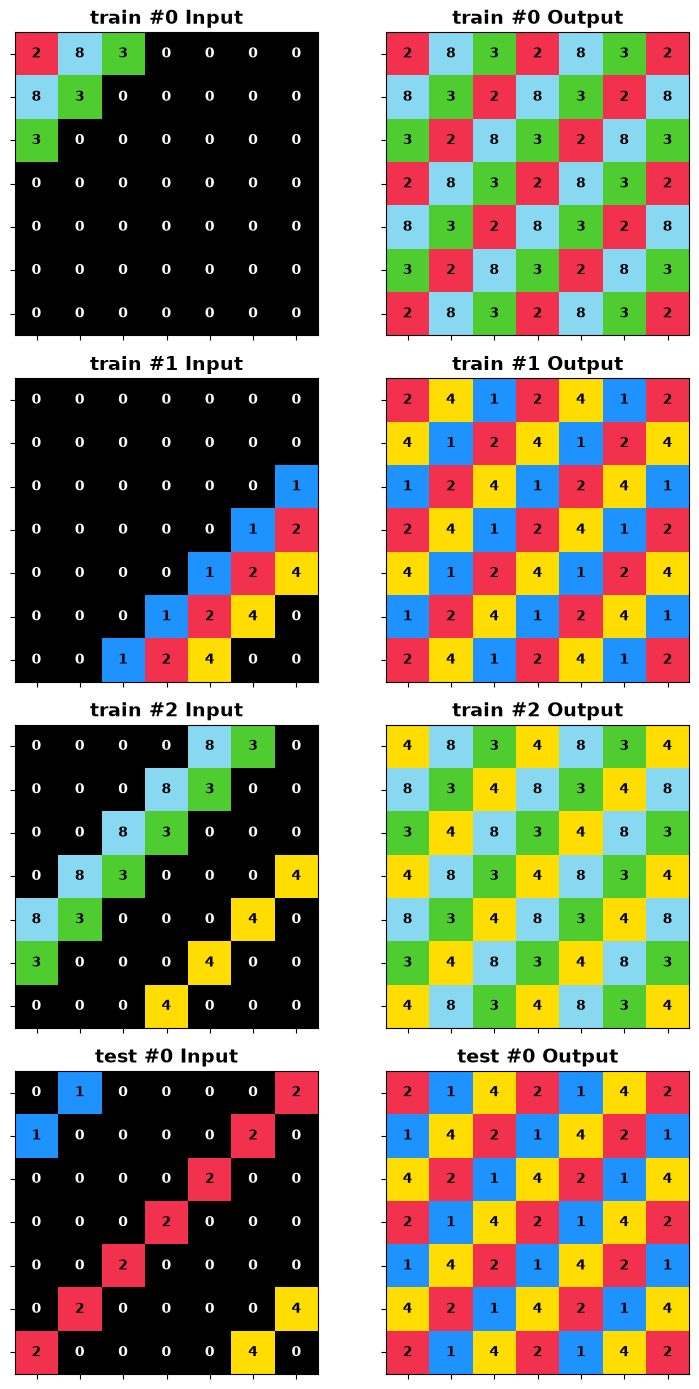

In [9]:
if rule is not None:
    name, H, W = rule
    transform_fn = TRANSFORMS[name]
    
    demos = []
    for split, examples in [('train', task['train']), ('test', task['test'])]:
        for i, ex in enumerate(examples):
            demos.append((split, i, ex))
    
    ncols = 4  # input, expected, predicted, diff
    nrows = len(demos)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
    if nrows == 1:
        axes = [axes]
    
    for row_idx, (split, i, ex) in enumerate(demos):
        inp = ex['input']
        expected = ex['output']
        
        # Build predicted output by applying transform
        predicted = [[0]*W for _ in range(H)]
        for r in range(H):
            for c in range(W):
                out_r, out_c = transform_fn(r, c, H, W)
                predicted[out_r][out_c] = inp[r][c]
        
        match = predicted == expected
        label = f'{split} #{i}' + (' OK' if match else ' FAIL')
        
        plot_grid(axes[row_idx][0], inp, f'Input ({H}x{W})')
        plot_grid(axes[row_idx][1], expected, 'Expected')
        plot_grid(axes[row_idx][2], predicted, f'Predicted ({name})')
        plot_diff(axes[row_idx][3], expected, predicted, label)
    
    fig.tight_layout()
    plt.show()
else:
    print('No rule found — showing raw demos.')
    demos = []
    for split, examples in [('train', task['train']), ('test', task['test'])]:
        for i, ex in enumerate(examples):
            demos.append((split, i, ex))
    
    ncols = 2
    nrows = len(demos)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
    if nrows == 1:
        axes = [axes]
    for row_idx, (split, i, ex) in enumerate(demos):
        plot_grid(axes[row_idx][0], ex['input'], f'{split} #{i} Input')
        plot_grid(axes[row_idx][1], ex['output'], f'{split} #{i} Output')
    fig.tight_layout()
    plt.show()

## 4. ONNX Model Verification
Run the actual ONNX model and compare byte-for-byte with expected.

In [5]:
import onnxruntime

model_path = f'output/task{TASK_NUM:03d}.onnx'
if not os.path.exists(model_path):
    print(f'{model_path} not found — run main.py first or pick a solved task (87, 140, 179, 380).')
else:
    session = onnxruntime.InferenceSession(model_path)
    
    all_examples = task['train'] + task['test'] + task['arc-gen']
    
    ncols = 5  # input, expected, onnx_output, grid_from_onnx, diff
    nrows = len(all_examples)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows))
    if nrows == 1:
        axes = [axes]
    
    for row_idx, ex in enumerate(all_examples):
        H, W = len(ex['input']), len(ex['input'][0])
        inp_tensor = grid_to_onehot(ex['input'], H, W)
        expected_tensor = grid_to_onehot(ex['output'], H, W)
        
        onnx_out = session.run(['output'], {'input': inp_tensor})[0]
        match = np.allclose(onnx_out, expected_tensor, atol=1e-6)
        
        # Convert ONNX output back to grid
        onnx_grid = []
        for r in range(H):
            row = []
            for c in range(W):
                ch = np.argmax(onnx_out[0, :, r, c])
                row.append(int(ch))
            onnx_grid.append(row)
        
        split = 'train' if row_idx < len(task['train']) else 'test'
        tag = f'{split}#{row_idx} {"OK" if match else "FAIL"}'
        
        plot_grid(axes[row_idx][0], ex['input'], 'Input')
        plot_grid(axes[row_idx][1], ex['output'], 'Expected')
        plot_grid(axes[row_idx][2], onnx_grid, 'ONNX Output')
        plot_diff(axes[row_idx][3], ex['output'], onnx_grid, tag)
        
        # Raw tensor diff
        axes[row_idx][4].imshow(np.abs(onnx_out[0].sum(axis=0) - expected_tensor[0].sum(axis=0)), cmap='gray')
        axes[row_idx][4].set_title('Tensor |diff|', fontsize=10)
        axes[row_idx][4].set_xticks([])
        axes[row_idx][4].set_yticks([])
    
    fig.tight_layout()
    plt.show()

output/task087.onnx not found — run main.py first or pick a solved task (87, 140, 179, 380).


## 5. Task Scanner
Quickly scan all tasks and show stats on which D4 symmetries are found.

In [ ]:
from collections import Counter

stats = Counter()
size_stats = Counter()

task_files = sorted(f for f in os.listdir(TASKS_DIR) if f.startswith('task') and f.endswith('.json'))
for tf in task_files:
    num = int(tf.replace('task', '').replace('.json', ''))
    t = load_task(num)
    exs = t['train'] + t['test']
    r = find_rule(exs)
    if r is None:
        stats['no_symmetry'] += 1
        # Why?
        sizes = set()
        for ex in exs:
            hi, wi = len(ex['input']), len(ex['input'][0])
            ho, wo = len(ex['output']), len(ex['output'][0])
            sizes.add((hi, wi, ho, wo))
        if any(h1 != h2 or w1 != w2 for h1, w1, h2, w2 in sizes):
            stats['size_mismatch'] += 1
        else:
            stats['no_match_in_d4'] += 1
    else:
        name, H, W = r
        stats[name] += 1
        size_stats[f'{H}x{W}'] += 1

print('=== D4 Symmetry Distribution ===')
for k, v in stats.most_common():
    print(f'  {k:25s} {v:4d}')

print(f'\n=== Grid Sizes (solved tasks) ===')
for k, v in size_stats.most_common():
    print(f'  {k:10s} {v:4d}')

## 6. Explore an Arbitrary Task (No Rule Required)
Just look at any task's input/output pairs visually.

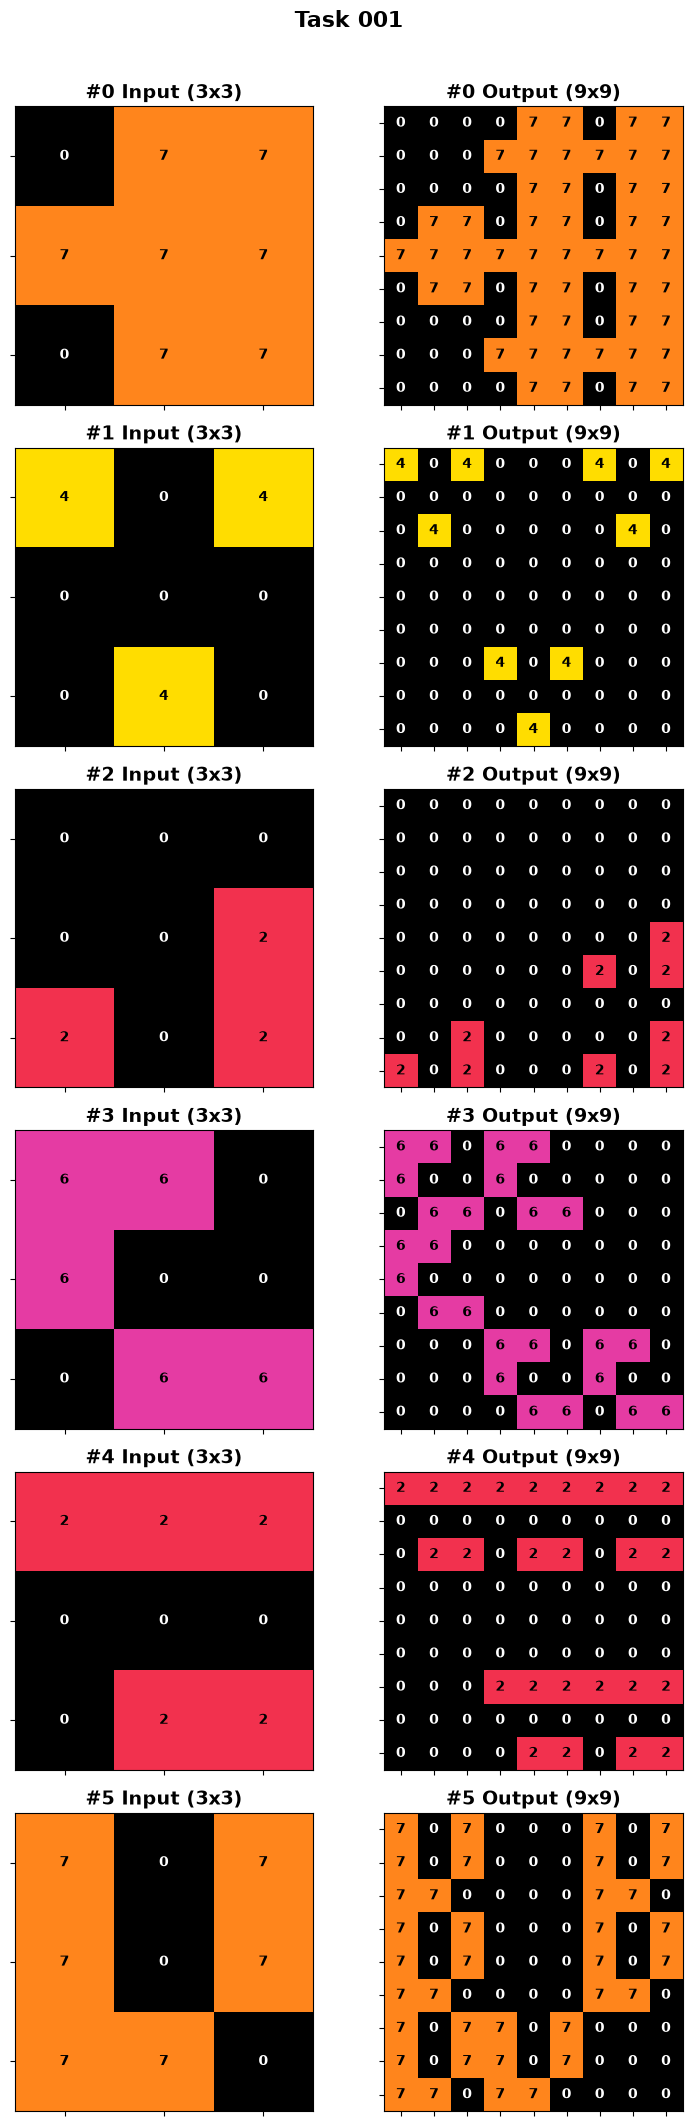

In [6]:
INSPECT_NUM = 1  # <-- change this to any task

t = load_task(INSPECT_NUM)
all_exs = t['train'] + t['test']

nrows = len(all_exs)
fig, axes = plt.subplots(nrows, 2, figsize=(8, 3.5*nrows))
if nrows == 1:
    axes = [axes]

for i, ex in enumerate(all_exs):
    plot_grid(axes[i][0], ex['input'], f'#{i} Input ({len(ex["input"])}x{len(ex["input"][0])})')
    plot_grid(axes[i][1], ex['output'], f'#{i} Output ({len(ex["output"])}x{len(ex["output"][0])})')

fig.suptitle(f'Task {INSPECT_NUM:03d}', fontsize=16, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()